# Dyck 5k_10k Experiment Overview

This notebook is a reusable overview for one experiment and covers:
1. **Pre-pretraining** curves by seed (formal-language training).
2. **Analysis** quality of analytic fits.
3. **Pretraining** downstream validation-loss curves by initialization choice.


In [21]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import platonic_init.aesthetics as aes

# Enable automatic reload for edits to platonic_init.aesthetics.
aes.enable_notebook_autoreload()
aes.set_theme(style='ticks', context='notebook')


def find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root')

ROOT = find_repo_root()

# ----- Select experiment here -----
EXPERIMENT_NAME = 'dyck_5k_10k'
MODEL_KEY = 'sshleifer_tiny-gpt2'

RUNS_PREPRETRAIN = ROOT / 'runs' / 'prepretraining' / EXPERIMENT_NAME / MODEL_KEY
ART_ANALYSIS = ROOT / 'artifacts' / 'experiments' / EXPERIMENT_NAME / 'analysis'
ART_BASIS_SWEEP = ART_ANALYSIS / 'basis_sweep'
ART_PRETRAIN = ROOT / 'artifacts' / 'experiments' / EXPERIMENT_NAME / 'pretraining'
CURVES_PATH = ART_PRETRAIN / 'init_eval_basis_curves.json'

print('RUNS_PREPRETRAIN:', RUNS_PREPRETRAIN)
print('ART_ANALYSIS:', ART_ANALYSIS)
print('ART_BASIS_SWEEP:', ART_BASIS_SWEEP)
print('ART_PRETRAIN:', ART_PRETRAIN)
print('CURVES_PATH exists:', CURVES_PATH.exists())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
RUNS_PREPRETRAIN: /Users/jacksonpetty/Development/platonic-init/runs/prepretraining/dyck_5k_10k/sshleifer_tiny-gpt2
ART_ANALYSIS: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_5k_10k/analysis
ART_BASIS_SWEEP: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_5k_10k/analysis/basis_sweep
ART_PRETRAIN: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_5k_10k/pretraining
CURVES_PATH exists: True


## Pre-pretraining Curves by Seed


In [22]:
def latest_trainer_state(seed_dir: Path) -> Path | None:
    ckpts = []
    for p in seed_dir.glob('checkpoint-*'):
        if not p.is_dir():
            continue
        try:
            step = int(p.name.split('-')[-1])
        except ValueError:
            continue
        state = p / 'trainer_state.json'
        if state.exists():
            ckpts.append((step, state))
    if not ckpts:
        return None
    ckpts.sort(key=lambda x: x[0])
    return ckpts[-1][1]

seed_dirs = sorted([p for p in RUNS_PREPRETRAIN.glob('seed_*') if p.is_dir()])
rows = []
for seed_dir in seed_dirs:
    seed_name = seed_dir.name
    state_path = latest_trainer_state(seed_dir)
    if state_path is None:
        continue
    state = json.loads(state_path.read_text(encoding='utf-8'))
    for entry in state.get('log_history', []):
        if 'loss' not in entry or 'step' not in entry:
            continue
        rows.append({
            'seed': seed_name,
            'step': int(entry['step']),
            'loss': float(entry['loss']),
        })

prepretrain_df = pd.DataFrame(rows).sort_values(['seed', 'step']).reset_index(drop=True)
print('Seeds with curves:', prepretrain_df['seed'].nunique())
print('Rows:', len(prepretrain_df))
prepretrain_df.head()


Seeds with curves: 8
Rows: 352


,seed,step,loss
0,seed_0,10,1.784043
1,seed_0,20,1.776092
2,seed_0,30,1.767031
3,seed_0,40,1.760291
4,seed_0,50,1.752086


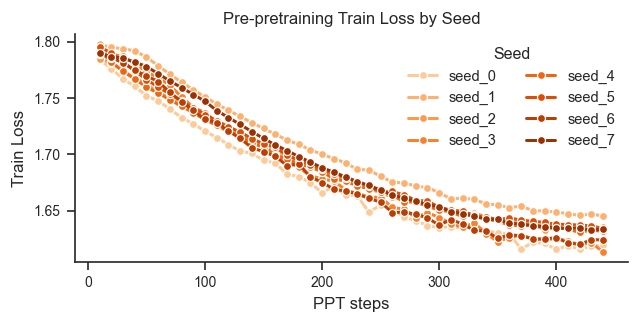

In [23]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLE_ROW_IN))

with sns.plotting_context('paper', font_scale=1, rc=aes.rcs):
    ax = fig.add_subplot(1, 1, 1)
    seed_order = sorted(prepretrain_df['seed'].unique().tolist())
    seed_palette = aes.make_seed_palette(seed_order)
    sns.lineplot(
        data=prepretrain_df,
        x='step',
        y='loss',
        hue='seed',
        hue_order=seed_order,
        palette=seed_palette,
        marker='o',
        linewidth=1.8,
        ax=ax,
    )

    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Pre-pretraining Train Loss by Seed')
    ax.set_xlabel('PPT steps')
    ax.set_ylabel('Train Loss')
    ax.legend(title='Seed', loc='best', ncol=2, frameon=False)

plt.tight_layout()
plt.show()


## Analysis: Analytic Fit Quality by Fit Block


In [24]:
fit_blocks_manifest_path = ART_BASIS_SWEEP / 'fit_blocks.json'
fit_manifest = {}
if fit_blocks_manifest_path.exists():
    fit_manifest = json.loads(fit_blocks_manifest_path.read_text(encoding='utf-8'))

fit_rows = []
for p in sorted(ART_BASIS_SWEEP.glob('analytic_fit_report_*.json')):
    slug = p.stem.replace('analytic_fit_report_', '')
    if slug == '':
        continue
    report = json.loads(p.read_text(encoding='utf-8'))

    fit_name = slug
    basis_type = slug
    for name, meta in fit_manifest.items():
        if meta.get('slug') == slug:
            fit_name = name
            basis_type = meta.get('basis_type', slug)
            break

    fit_rows.append({
        'fit_name': fit_name,
        'basis_type': basis_type,
        'slug': slug,
        'mean_relative_error': float(report['mean_relative_error']),
    })

fit_df = pd.DataFrame(fit_rows).sort_values('fit_name').reset_index(drop=True)
fit_df


,fit_name,basis_type,slug,mean_relative_error
0,chebyshev,chebyshev,chebyshev,0.210661
1,chebyshev_d128,chebyshev,chebyshev_d128,0.116752
2,chebyshev_d24,chebyshev,chebyshev_d24,0.118305
3,chebyshev_d48,chebyshev,chebyshev_d48,0.117944
4,chebyshev_d6,chebyshev,chebyshev_d6,0.392371


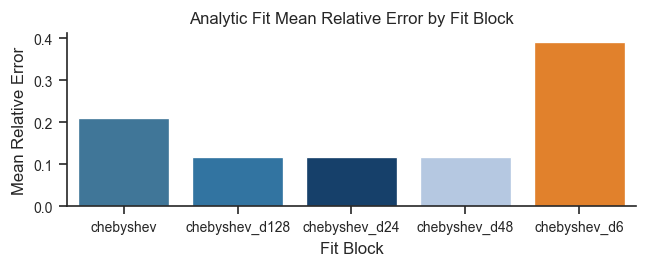

In [25]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLE_ROW_IN * 1.8))

with sns.plotting_context('paper', font_scale=1, rc=aes.rcs):
    ax = fig.add_subplot(1, 1, 1)
    fit_palette = aes.make_init_palette(fit_df['fit_name'].tolist())
    sns.barplot(
        data=fit_df,
        x='fit_name',
        y='mean_relative_error',
        hue='fit_name',
        palette=fit_palette,
        legend=False,
        ax=ax,
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Analytic Fit Mean Relative Error by Fit Block')
    ax.set_xlabel('Fit Block')
    ax.set_ylabel('Mean Relative Error')

plt.tight_layout()
plt.show()


## Pretraining: Downstream Validation-Loss Curves by Initialization
Includes random, basis-derived initialization(s), and weight transfer control.


In [12]:
payload = json.loads(CURVES_PATH.read_text(encoding='utf-8'))
results = payload['results']
print('init_mode:', payload.get('init_mode'))
print('train_steps:', payload.get('train_steps'))
print('eval_every:', payload.get('eval_every'))
print('labels:', [r['label'] for r in results])

summary_rows = []
curve_rows = []
for r in results:
    label = r['label']
    summary_rows.append({
        'init': label,
        'initial_eval_loss': float(r.get('initial_eval_loss', float('nan'))),
        'best_eval_loss': float(r.get('best_eval_loss', float('nan'))),
        'final_eval_loss': float(r.get('final_eval_loss', r.get('eval_loss', float('nan')))),
    })
    for point in r.get('eval_curve', []):
        curve_rows.append({
            'init': label,
            'step': int(point['step']),
            'eval_loss': float(point['eval_loss']),
        })

summary_df = pd.DataFrame(summary_rows).sort_values('final_eval_loss').reset_index(drop=True)
curve_df = pd.DataFrame(curve_rows).sort_values(['init', 'step']).reset_index(drop=True)
summary_df


init_mode: sampled
train_steps: 10000
eval_every: 100
labels: ['random', 'chebyshev_d6', 'chebyshev', 'chebyshev_d24', 'chebyshev_d48', 'chebyshev_d128', 'weight_transfer']


,init,initial_eval_loss,best_eval_loss,final_eval_loss
0,weight_transfer,10.575343,7.310821,7.310989
1,chebyshev_d6,10.571904,7.310940,7.311035
2,chebyshev,10.572440,7.310975,7.311103
3,chebyshev_d24,10.573874,7.311082,7.311229
4,chebyshev_d128,10.573967,7.311216,7.311248
5,random,10.576051,7.311095,7.311328
6,chebyshev_d48,10.573898,7.311249,7.311371


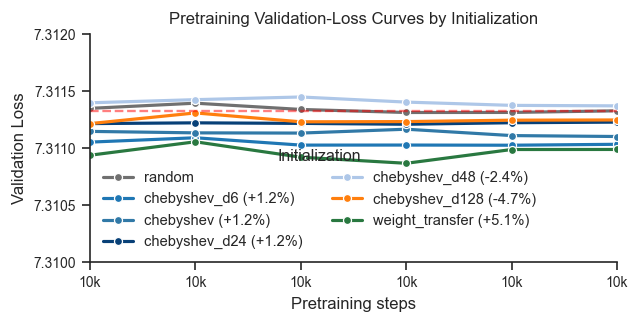

In [20]:
preferred_order = ['random']
preferred_order.extend(payload.get('fit_names', []))
if 'weight_transfer' in set(curve_df['init']):
    preferred_order.append('weight_transfer')

available = [x for x in preferred_order if x in set(curve_df['init'])]
remaining = sorted([x for x in set(curve_df['init']) if x not in available])
hue_order = available + remaining

fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLE_ROW_IN))

with sns.plotting_context('paper', font_scale=1, rc=aes.rcs):
    ax = fig.add_subplot(1, 1, 1)
    palette = aes.make_init_palette(hue_order)
    sns.lineplot(
        data=curve_df,
        x='step',
        y='eval_loss',
        hue='init',
        hue_order=hue_order,
        palette=palette,
        marker='o',
        linewidth=1.9,
        ax=ax,
    )

    legend_labels = {name: name for name in hue_order}
    random_curve = curve_df[curve_df['init'] == 'random'].sort_values('step')
    if not random_curve.empty:
        random_final_loss = float(random_curve.iloc[-1]['eval_loss'])
        ax.axhline(random_final_loss, color='red', alpha=0.5, linewidth=1.4, linestyle='--')

        random_hit = random_curve[random_curve['eval_loss'] <= random_final_loss]
        random_steps_to_target = float(random_hit.iloc[0]['step']) if not random_hit.empty else float(random_curve.iloc[-1]['step'])

        for init_name in hue_order:
            if init_name == 'random':
                continue
            c = curve_df[curve_df['init'] == init_name].sort_values('step')
            if c.empty:
                continue
            hit = c[c['eval_loss'] <= random_final_loss]
            if hit.empty:
                legend_labels[init_name] = f'{init_name} (n/a)'
                continue
            steps_to_target = float(hit.iloc[0]['step'])
            if steps_to_target <= 0:
                legend_labels[init_name] = f'{init_name} (n/a)'
                continue
            speedup_pct = (random_steps_to_target / steps_to_target - 1.0) * 100.0
            legend_labels[init_name] = f'{init_name} ({speedup_pct:+.1f}%)'

    x_min = float(curve_df['step'].min())
    x_max = float(curve_df['step'].max())
    y_min = float(curve_df['eval_loss'].min())
    y_max = float(curve_df['eval_loss'].max())
    y_pad = max(0.01, (y_max - y_min) * 0.08)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Pretraining Validation-Loss Curves by Initialization')
    ax.set_xlabel('Pretraining steps')
    ax.set_ylabel('Validation Loss')

    handles, labels = ax.get_legend_handles_labels()
    if labels and labels[0] == 'init':
        handles = handles[1:]
        labels = labels[1:]
    labels = [legend_labels.get(lbl, lbl) for lbl in labels]
    ax.legend(handles, labels, title='Initialization', loc='best', ncol=2, frameon=False)

    ax.set_xlim(left=9500,)
    ax.set_ylim(top=7.312, bottom=7.31)

plt.tight_layout()
plt.show()


## Pretraining: Speedup Over Time vs Random
Shows step-wise speedup for each initialization based on time-to-reach the same eval loss as random.


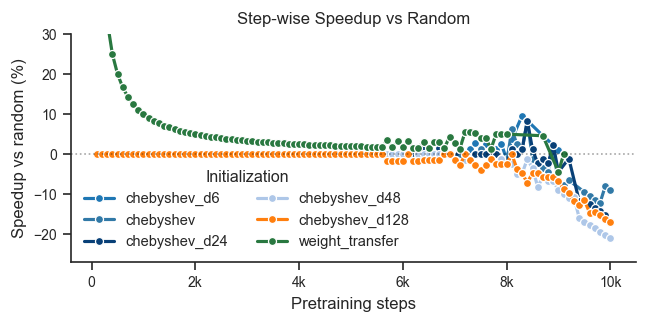

In [14]:
random_curve = curve_df[curve_df['init'] == 'random'].sort_values('step').drop_duplicates('step')
if random_curve.empty:
    raise ValueError('Random initialization curve is required for speedup plot')

random_steps = random_curve['step'].to_numpy()
random_losses = random_curve['eval_loss'].to_numpy()

speed_rows = []
for init_name in sorted(set(curve_df['init'])):
    if init_name == 'random':
        continue
    init_curve = curve_df[curve_df['init'] == init_name].sort_values('step').drop_duplicates('step')
    for _, row in init_curve.iterrows():
        step = float(row['step'])
        loss = float(row['eval_loss'])
        hits = random_curve[random_curve['eval_loss'] <= loss]
        if hits.empty or step <= 0:
            continue
        random_step_to_same_loss = float(hits.iloc[0]['step'])
        speedup_pct = (random_step_to_same_loss / step - 1.0) * 100.0
        speed_rows.append({
            'init': init_name,
            'step': step,
            'speedup_pct': speedup_pct,
        })

speed_df = pd.DataFrame(speed_rows)
if speed_df.empty:
    raise ValueError('No comparable speedup points found; random may not have reached peer losses yet.')

speed_hue_order = [x for x in hue_order if x in set(speed_df['init']) and x != 'random']
speed_palette = aes.make_init_palette(speed_hue_order)

fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLE_ROW_IN))
with sns.plotting_context('paper', font_scale=1, rc=aes.rcs):
    ax = fig.add_subplot(1, 1, 1)
    sns.lineplot(
        data=speed_df,
        x='step',
        y='speedup_pct',
        hue='init',
        hue_order=speed_hue_order,
        palette=speed_palette,
        marker='o',
        linewidth=1.9,
        ax=ax,
    )

    ax.axhline(0.0, color='black', alpha=0.35, linewidth=1.0, linestyle=':')
    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Step-wise Speedup vs Random')
    ax.set_xlabel('Pretraining steps')
    ax.set_ylabel('Speedup vs random (%)')
    ax.legend(title='Initialization', loc='best', ncol=2, frameon=False)

    ax.set_ylim(top=30)

plt.tight_layout()
plt.show()
